In [ ]:
import os
import elevation

# 1. Define your specific folder
output_dir = './maps'
filename = 'Austria-DEM.tif'
full_output_path = os.path.join(output_dir, filename)

# Ensure the folder actually exists
os.makedirs(output_dir, exist_ok=True)

elevation.clip(bounds=(9.527, 46.372, 17.161, 49.021), output=full_output_path, max_download_tiles=50)
elevation.clean()

## Creating a "true" to color map with elevation labelled in feet

Fetching 10m high-detail boundaries...
Clipping Austria-DEM.tif...
Saving to Austria_Alpine_Map_ft.png...


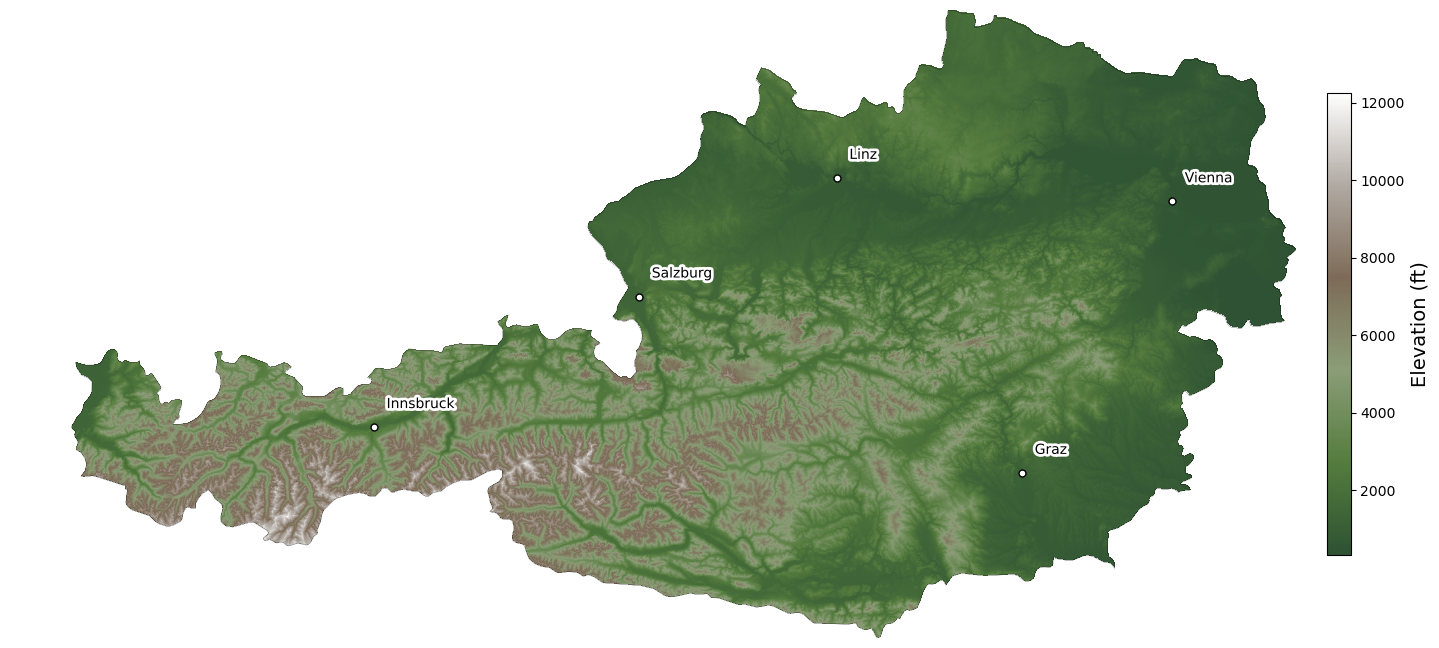

In [11]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Austria-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

# Major Austrian cities (Lon, Lat)
cities = {
    "Vienna": (16.373, 48.208),
    "Salzburg": (13.055, 47.809),
    "Innsbruck": (11.404, 47.262),
    "Graz": (15.439, 47.070),
    "Linz": (14.285, 48.306)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (National Level)
print("Fetching 10m high-detail boundaries...")
# Changing 'admin_1_states_provinces' to 'admin_0_countries' for a nation
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_0_countries')
world = gpd.read_file(shpfilename)

# Filter for Austria
austria = world[world['NAME'] == 'Austria']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    austria = austria.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, austria.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Elevation in Meters (Standard for Europe)
    # If you prefer feet, keep the * 3.28084 multiplier
    elevation = elevation * 3.28084
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# 2. COLORMAP SETUP (Alpine Palette)
alpine_colors = [
    (0.0,  "#2E5233"),  # Deep Valley Green
    (0.2,  "#557C3E"),  # Forest Green
    (0.4,  "#8B9D77"),  # Alpine Meadow
    (0.6,  "#7D6B58"),  # Mountain Rock
    (0.8,  "#B0A9A2"),  # High Scree/Slate
    (1.0,  "#FFFFFF")   # Permanent Snow/Glaciers
]
custom_terrain = mcolors.LinearSegmentedColormap.from_list("Alpine", alpine_colors)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Plotting with the custom Alpine colormap
im = ax.imshow(elevation, extent=extent, cmap=custom_terrain, origin='upper', interpolation='none')
# im = ax.imshow(elevation, extent=extent, cmap='Spectral', origin='upper', interpolation='none')

# Draw the high-detail border
austria.boundary.plot(ax=ax, color='black', linewidth=0.2, zorder=10)

# # 4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])


# 5. EXPORT
cb = plt.colorbar(im, shrink=0.3, pad=0.02)
cb.set_label('Elevation (ft)', fontsize=14)
ax.axis('off')

output_filename = "Austria_Alpine_Map_ft.png"
print(f"Saving to {output_filename}...")
plt.savefig(output_filename, dpi=360, bbox_inches='tight', pad_inches=0.1)

plt.show()

## Creating a "true" to color map with elevation labelled in meters

Fetching 10m high-detail boundaries...
Clipping Austria-DEM.tif...
Saving to Austria_Alpine_Map_m.png...


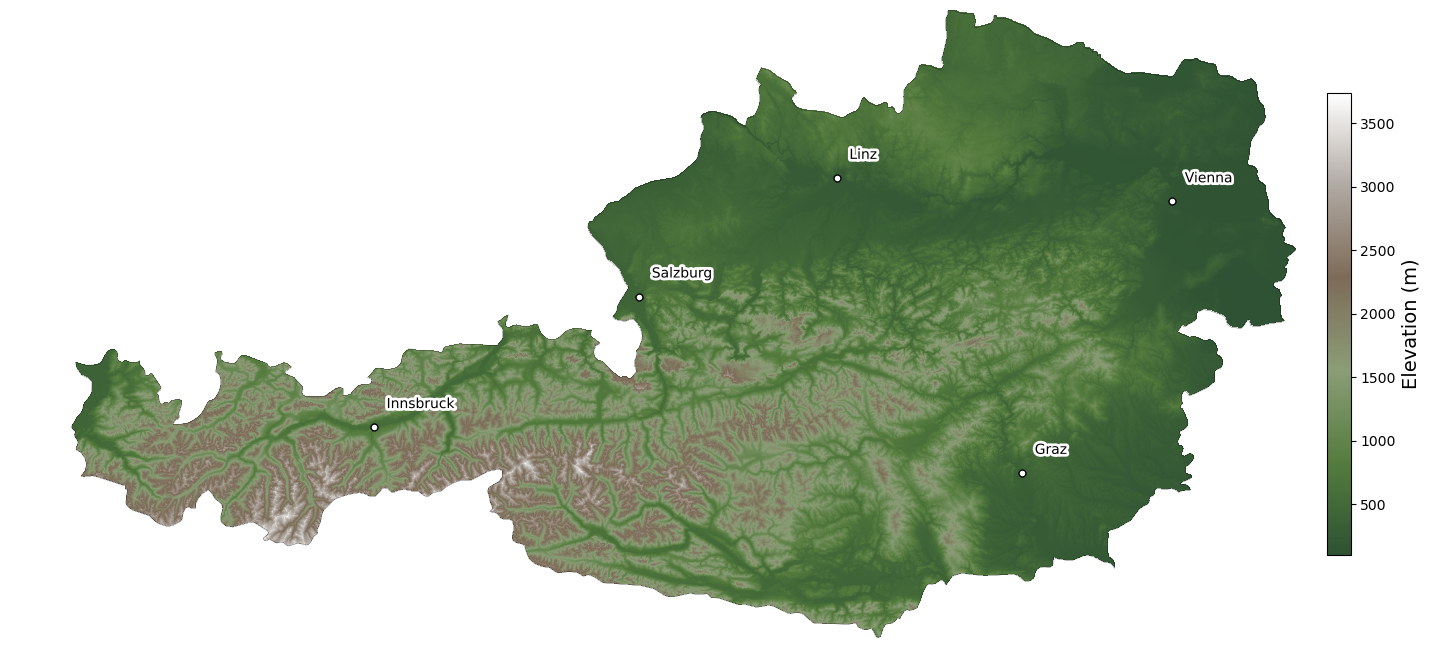

In [12]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Austria-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

# Major Austrian cities (Lon, Lat)
cities = {
    "Vienna": (16.373, 48.208),
    "Salzburg": (13.055, 47.809),
    "Innsbruck": (11.404, 47.262),
    "Graz": (15.439, 47.070),
    "Linz": (14.285, 48.306)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (National Level)
print("Fetching 10m high-detail boundaries...")
# Changing 'admin_1_states_provinces' to 'admin_0_countries' for a nation
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_0_countries')
world = gpd.read_file(shpfilename)

# Filter for Austria
austria = world[world['NAME'] == 'Austria']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    austria = austria.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, austria.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Elevation in Meters (Standard for Europe)
    # If you prefer feet, keep the * 3.28084 multiplier
    elevation = elevation
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# 2. COLORMAP SETUP (Alpine Palette)
alpine_colors = [
    (0.0,  "#2E5233"),  # Deep Valley Green
    (0.2,  "#557C3E"),  # Forest Green
    (0.4,  "#8B9D77"),  # Alpine Meadow
    (0.6,  "#7D6B58"),  # Mountain Rock
    (0.8,  "#B0A9A2"),  # High Scree/Slate
    (1.0,  "#FFFFFF")   # Permanent Snow/Glaciers
]
custom_terrain = mcolors.LinearSegmentedColormap.from_list("Alpine", alpine_colors)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Plotting with the custom Alpine colormap
im = ax.imshow(elevation, extent=extent, cmap=custom_terrain, origin='upper', interpolation='none')
# im = ax.imshow(elevation, extent=extent, cmap='Spectral', origin='upper', interpolation='none')

# Draw the high-detail border
austria.boundary.plot(ax=ax, color='black', linewidth=0.2, zorder=10)

# # 4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])


# 5. EXPORT
cb = plt.colorbar(im, shrink=0.3, pad=0.02)
cb.set_label('Elevation (m)', fontsize=14)
ax.axis('off')

output_filename = "Austria_Alpine_Map_m.png"
print(f"Saving to {output_filename}...")
plt.savefig(output_filename, dpi=360, bbox_inches='tight', pad_inches=0.1)

plt.show()

## Creating a Spectral_r map with elevation labelled in feet

Fetching 10m high-detail boundaries...
Clipping Austria-DEM.tif...
Saving to Austria_Spectral_r_Map_ft.png...


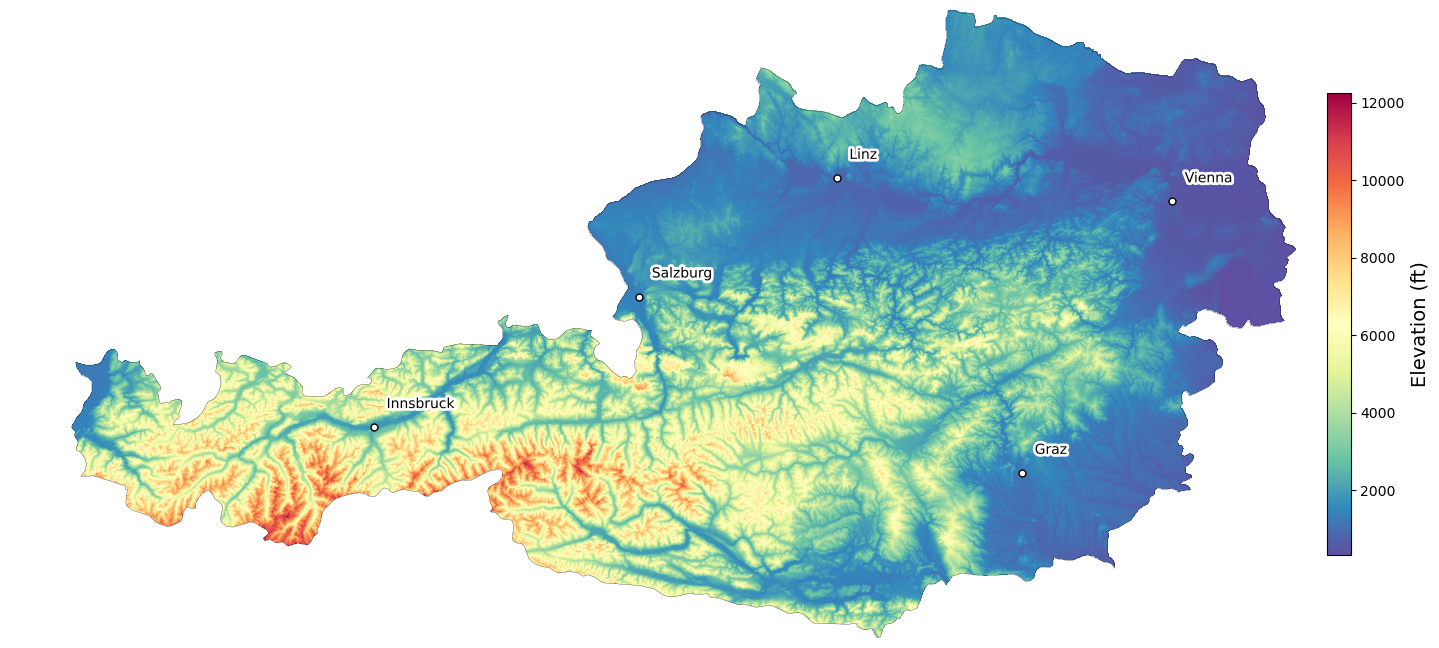

In [13]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Austria-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

# Major Austrian cities (Lon, Lat)
cities = {
    "Vienna": (16.373, 48.208),
    "Salzburg": (13.055, 47.809),
    "Innsbruck": (11.404, 47.262),
    "Graz": (15.439, 47.070),
    "Linz": (14.285, 48.306)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (National Level)
print("Fetching 10m high-detail boundaries...")
# Changing 'admin_1_states_provinces' to 'admin_0_countries' for a nation
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_0_countries')
world = gpd.read_file(shpfilename)

# Filter for Austria
austria = world[world['NAME'] == 'Austria']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    austria = austria.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, austria.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Elevation in Meters (Standard for Europe)
    # If you prefer feet, keep the * 3.28084 multiplier
    elevation = elevation * 3.28084
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# # 2. COLORMAP SETUP (Alpine Palette)
# alpine_colors = [
#     (0.0,  "#2E5233"),  # Deep Valley Green
#     (0.2,  "#557C3E"),  # Forest Green
#     (0.4,  "#8B9D77"),  # Alpine Meadow
#     (0.6,  "#7D6B58"),  # Mountain Rock
#     (0.8,  "#B0A9A2"),  # High Scree/Slate
#     (1.0,  "#FFFFFF")   # Permanent Snow/Glaciers
# ]
# custom_terrain = mcolors.LinearSegmentedColormap.from_list("Alpine", alpine_colors)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Plotting with the custom Alpine colormap
# im = ax.imshow(elevation, extent=extent, cmap=custom_terrain, origin='upper', interpolation='none')
im = ax.imshow(elevation, extent=extent, cmap='Spectral_r', origin='upper', interpolation='none')

# Draw the high-detail border
austria.boundary.plot(ax=ax, color='black', linewidth=0.2, zorder=10)

# # 4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])


# 5. EXPORT
cb = plt.colorbar(im, shrink=0.3, pad=0.02)
cb.set_label('Elevation (ft)', fontsize=14)
ax.axis('off')

output_filename = "Austria_Spectral_r_Map_ft.png"
print(f"Saving to {output_filename}...")
plt.savefig(output_filename, dpi=360, bbox_inches='tight', pad_inches=0.1)

plt.show()

## Creating a Spectral_r map with elevation labelled in meters

Fetching 10m high-detail boundaries...
Clipping Austria-DEM.tif...
Saving to Austria_Spectral_r_Map_m.png...


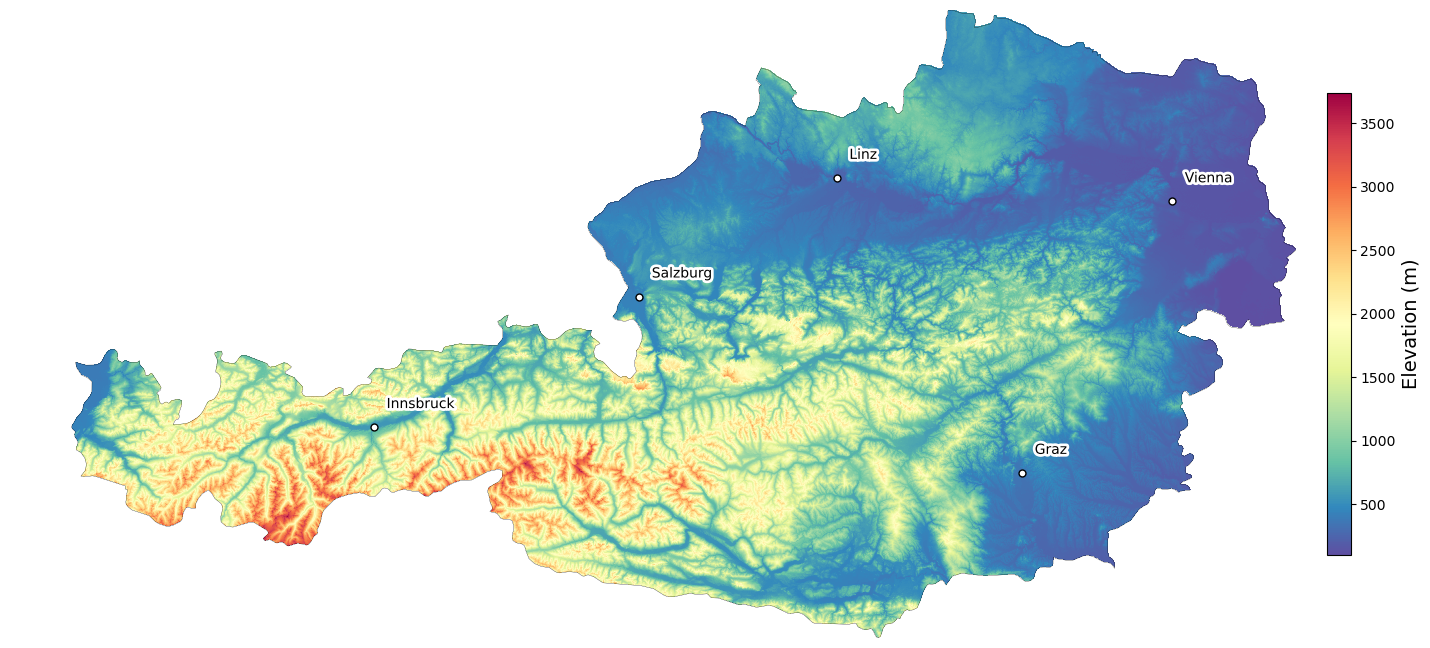

In [14]:
import rasterio
import rasterio.mask
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from rasterio.plot import plotting_extent

# --- CONFIGURATION ---
dem_file = 'Austria-DEM.tif' 
DOWNSAMPLE_FACTOR = 2  # 1 for maximum pixel detail

# Major Austrian cities (Lon, Lat)
cities = {
    "Vienna": (16.373, 48.208),
    "Salzburg": (13.055, 47.809),
    "Innsbruck": (11.404, 47.262),
    "Graz": (15.439, 47.070),
    "Linz": (14.285, 48.306)
}
# ---------------------

# 1. GET HIGH-DETAIL BORDERS (National Level)
print("Fetching 10m high-detail boundaries...")
# Changing 'admin_1_states_provinces' to 'admin_0_countries' for a nation
shpfilename = shpreader.natural_earth(resolution='10m',
                                      category='cultural',
                                      name='admin_0_countries')
world = gpd.read_file(shpfilename)

# Filter for Austria
austria = world[world['NAME'] == 'Austria']

print(f"Clipping {dem_file}...")
with rasterio.open(dem_file) as src:
    austria = austria.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, austria.geometry, crop=True)
    
    elevation = out_image[0].astype('float32')
    nodata_val = src.nodata if src.nodata is not None else 0
    elevation[elevation == nodata_val] = np.nan
    
    # Elevation in Meters (Standard for Europe)
    # If you prefer feet, keep the * 3.28084 multiplier
    elevation = elevation
    
    # Downsample
    elevation = elevation[::DOWNSAMPLE_FACTOR, ::DOWNSAMPLE_FACTOR]
    extent = plotting_extent(out_image[0], out_transform)

# # 2. COLORMAP SETUP (Alpine Palette)
# alpine_colors = [
#     (0.0,  "#2E5233"),  # Deep Valley Green
#     (0.2,  "#557C3E"),  # Forest Green
#     (0.4,  "#8B9D77"),  # Alpine Meadow
#     (0.6,  "#7D6B58"),  # Mountain Rock
#     (0.8,  "#B0A9A2"),  # High Scree/Slate
#     (1.0,  "#FFFFFF")   # Permanent Snow/Glaciers
# ]
# custom_terrain = mcolors.LinearSegmentedColormap.from_list("Alpine", alpine_colors)

# 3. PLOTTING
fig, ax = plt.subplots(figsize=(20, 20))
ax.set_facecolor('#f8f9fa') 

# Plotting with the custom Alpine colormap
# im = ax.imshow(elevation, extent=extent, cmap=custom_terrain, origin='upper', interpolation='none')
im = ax.imshow(elevation, extent=extent, cmap='Spectral_r', origin='upper', interpolation='none')

# Draw the high-detail border
austria.boundary.plot(ax=ax, color='black', linewidth=0.2, zorder=10)

# # 4. ADD CITY LABELS
for city, coord in cities.items():
    lon, lat = coord
    ax.plot(lon, lat, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=15)
    # txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=7, fontweight='bold', zorder=16)
    txt = ax.text(lon + 0.08, lat + 0.08, city, fontsize=10, zorder=16)
    txt.set_path_effects([path_effects.withStroke(linewidth=4, foreground='white')])


# 5. EXPORT
cb = plt.colorbar(im, shrink=0.3, pad=0.02)
cb.set_label('Elevation (m)', fontsize=14)
ax.axis('off')

output_filename = "Austria_Spectral_r_Map_m.png"
print(f"Saving to {output_filename}...")
plt.savefig(output_filename, dpi=360, bbox_inches='tight', pad_inches=0.1)

plt.show()